# M5 EDA

Revenue concentration, demand variability and event associations are cohort-specific.

Run the CLI first. Default RUN is fixture; change only after processing real data.

In [1]:
from pathlib import Path
import pandas as pd
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
RUN = 'fixture'
OUT = ROOT / 'data/powerbi' / RUN
def read(name):
    return pd.read_parquet(OUT / (name + '.parquet'))
assert OUT.exists(), 'Run python src/run_pipeline.py --mode sample --fixture first'


,item_id,store_id,category_id,department_id,state_id,average_daily_demand,demand_std,revenue,units_sold,zero_demand_share,last_price,abc,coefficient_of_variation,xyz,abc_xyz,volume_segment,cumulative_revenue_share
0,SYNTH_009,TX_1,C0,D0,TX,5.344444,2.509134,3992.3,481.0,0.000000,8.3,A,0.469485,X,A-X,high,0.092437
1,SYNTH_009,CA_1,C0,D0,CA,5.111111,2.474338,3818.0,460.0,0.011111,8.3,A,0.484110,X,A-X,high,0.180839
2,SYNTH_008,CA_1,C0,D2,CA,4.944444,2.205005,3382.0,445.0,0.000000,7.6,A,0.445956,X,A-X,high,0.259145
3,SYNTH_008,TX_1,C0,D2,TX,4.444444,2.141674,3040.0,400.0,0.000000,7.6,A,0.481877,X,A-X,high,0.329533
4,SYNTH_012,TX_1,C0,D0,TX,3.244444,1.794568,3036.8,292.0,0.022222,10.4,A,0.553120,Y,A-Y,medium,0.399847
5,SYNTH_012,CA_1,C0,D0,CA,3.066667,1.964860,2870.4,276.0,0.022222,10.4,A,0.640715,Y,A-Y,medium,0.466308
6,SYNTH_007,CA_1,C1,D1,CA,3.644444,1.769346,2263.2,328.0,0.022222,6.9,A,0.485491,X,A-X,medium,0.518709
7,SYNTH_004,TX_1,C1,D1,TX,5.200000,2.690808,2246.4,468.0,0.011111,4.8,A,0.517463,Y,A-Y,high,0.570722
8,SYNTH_007,TX_1,C1,D1,TX,3.611111,1.987005,2242.5,325.0,0.033333,6.9,A,0.550248,Y,A-Y,medium,0.622645
9,SYNTH_004,CA_1,C1,D1,CA,5.011111,2.519561,2164.8,451.0,0.000000,4.8,A,0.502795,Y,A-Y,high,0.672768


,event_name,units_sold,revenue,mean_series_day_units,series_days
0,Synthetic Festival,1115.0,7195.1,4.645833,240
1,None,44014.0,283198.5,3.108333,14160


abc_xyz
A-X    6
A-Y    7
B-Y    6
C-Y    1
C-Z    4
dtype: int64

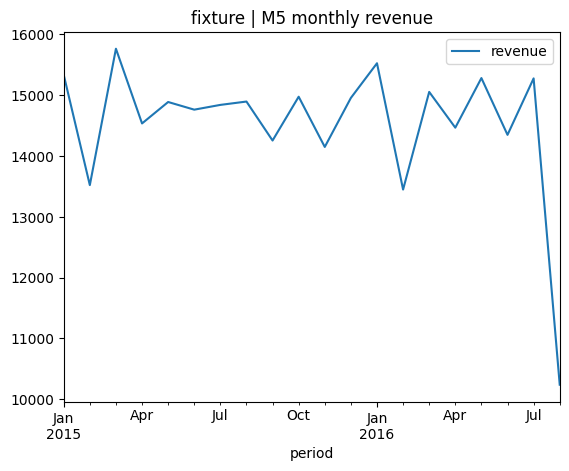

In [2]:
perf = read('product_store_performance')
display(perf.sort_values('revenue', ascending=False).head(20))
read('sales_monthly').plot(x='period', y='revenue', title=RUN + ' | M5 monthly revenue')
display(read('m5_by_event_name'))
display(read('abc_xyz_segmentation').groupby('abc_xyz').size())
